# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [14]:
df = pd.read_csv("Base_dados_mercado.csv", delimiter=',')

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [18]:
media_categoria = df.groupby("Categoria")["Preco_Normal"].mean()
print(media_categoria)

Categoria
belleza-y-cuidado-personal    1783.556485
comidas-preparadas            3095.043478
congelados                    2108.042553
frutas                        1724.473684
instantaneos-y-sopas           765.491228
lacteos                       2385.219239
verduras                      1343.296875
Name: Preco_Normal, dtype: float64


In [31]:
mediana_categoria = df.groupby("Categoria")["Preco_Normal"].median()


print(mediana_categoria)


Categoria
belleza-y-cuidado-personal    1569.0
comidas-preparadas            3290.0
congelados                    1519.0
frutas                        1195.0
instantaneos-y-sopas           439.0
lacteos                        989.0
verduras                      1180.0
Name: Preco_Normal, dtype: float64


Digite aqui as categorias: 

a categoria lacteos chama a atenção por ter uma média muito maior do que a mediana. A categoria comidas-preparadas é a única categoria que tem a média menor do que a mediana. Todas as outras categorias tem a média maior que a mediana.


# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [25]:
desvio_categoria = df.groupby("Categoria")["Preco_Normal"].std()

print(desvio_categoria)


Categoria
belleza-y-cuidado-personal    2210.041719
comidas-preparadas            2019.911428
congelados                    2111.539896
frutas                        1639.151114
instantaneos-y-sopas          1170.232869
lacteos                       3925.816164
verduras                      1012.699625
Name: Preco_Normal, dtype: float64


In [30]:
tabela_info = pd.DataFrame({
    "Média": media_categoria,
    "Mediana": mediana_categoria,
    "Desvio Padrão": desvio_categoria
})

print(tabela_info)

                                  Média  Mediana  Desvio Padrão
Categoria                                                      
belleza-y-cuidado-personal  1783.556485   1569.0    2210.041719
comidas-preparadas          3095.043478   3290.0    2019.911428
congelados                  2108.042553   1519.0    2111.539896
frutas                      1724.473684   1195.0    1639.151114
instantaneos-y-sopas         765.491228    439.0    1170.232869
lacteos                     2385.219239    989.0    3925.816164
verduras                    1343.296875   1180.0    1012.699625


Digite nesse campo o comportamento que você identificou.

Na categoria com o maior desvio padrão (lacteos) a média é muito mais alta que a mediana.
Já na categoria verduras, que tem o menor desvio padrao, a média a mediana são mais parecidas.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

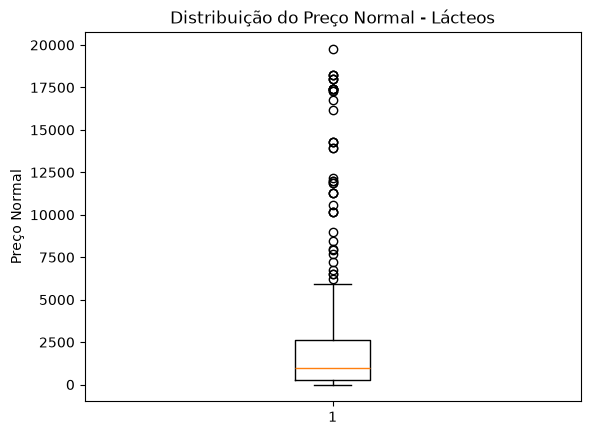

In [37]:
dados_lacteos = df[df["Categoria"] == "lacteos"]

plt.boxplot(dados_lacteos["Preco_Normal"])

plt.title("Distribuição do Preço Normal - Lácteos")
plt.ylabel("Preço Normal")

plt.show()

Pude observar que a grande maioria dos dados se encontram acima da mediana e que existem muitos outliers.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

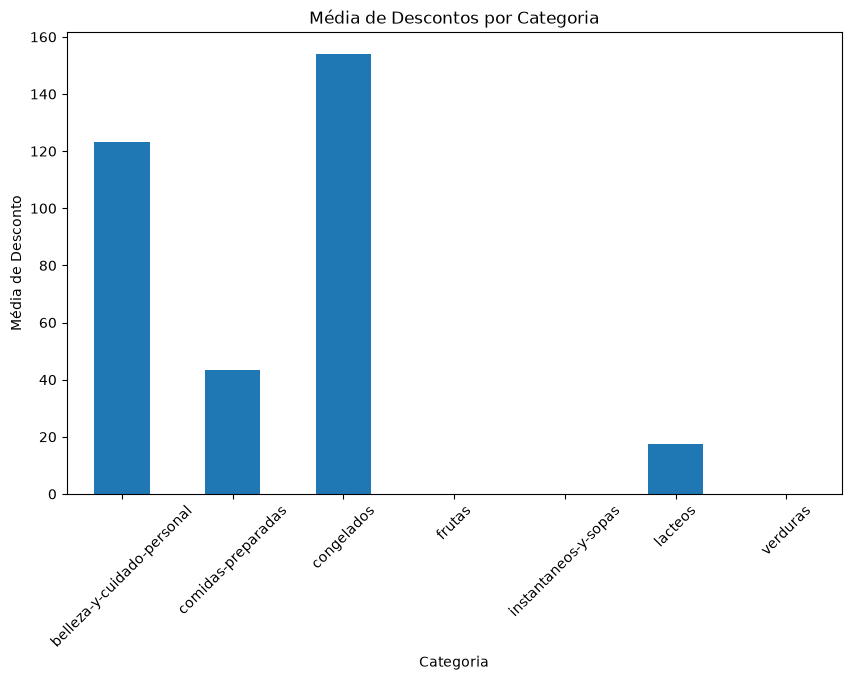

In [38]:
# Seu código aqui
media_desconto = df.groupby("Categoria")["Desconto"].mean()

media_desconto.plot(
    kind="bar",
    figsize=(10, 6),
    title="Média de Descontos por Categoria"
)

plt.xlabel("Categoria")
plt.ylabel("Média de Desconto")
plt.xticks(rotation=45)
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [42]:
# Seu código aqui
import plotly.express as px

media_desconto = (
    df.groupby(["Categoria", "Marca"])["Desconto"]
    .mean()
    .reset_index()
)

fig = px.treemap(
    media_desconto,
    path=["Categoria", "Marca"],
    values="Desconto",
    color="Desconto",
    title="Média de Desconto por Categoria e Marca"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed